# Evaluating Classification Models

## Table of Contents
- [4.1.1 Confusion Matrix](#411-confusion-matrix)
- [4.1.2 Accuracy, Precision, Recall, F1-Score](#412-accuracy-precision-recall-f1-score)
- [4.1.3 ROC Curves & AUC](#413-roc-curves--auc)
- [Knowledge Check](#knowledge-check)
- [Mini-Challenges](#mini-challenges)
- [Practical Connections](#practical-connections)

## Introduction

Classification models need proper evaluation beyond just training accuracy. In this notebook, we'll explore key metrics to assess how well a model performs on unseen data.

These evaluation techniques help us understand:
- **What types of errors** the model makes (confusion matrix)
- **How balanced** the model's predictions are (precision vs. recall)
- **How well it generalizes** across different classification thresholds (ROC curves)

We'll start by importing the necessary libraries and then work through practical examples using real datasets.

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    classification_report, 
    roc_curve, 
    roc_auc_score
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 4.1.1 Confusion Matrix



### What is it?
A confusion matrix is a table that summarizes the performance of a classification model by comparing the predicted class labels against the true class labels for a set of data (usually the test set). It's the foundation for most other classification metrics.

### Structure (for Binary Classification):

| | Predicted: Negative (Normal email) | Predicted: Positive (Spam email) |
|------------------ | ---------------------- | ---------------------- |
| **Actual: Negative (Normal email)** | True Negative (TN) | False Positive (FP) |
| **Actual: Positive (pam email)** | False Negative (FN) | True Positive (TP) |

**Key Terms:**
* **True Positive (TP):** The model correctly predicted the positive class (e.g., correctly detected spam).
* **True Negative (TN):** The model correctly predicted the negative class (e.g., correctly identified a normal email).
* **False Positive (FP):** The model incorrectly predicted positive (e.g., flagged a normal email as spam). Also known as a **Type I Error**.
* **False Negative (FN):** The model incorrectly predicted negative (e.g., missed a spam email). Also known as a **Type II Error**.

### Why useful?
It breaks down the errors, showing *what kind* of mistakes the model is making. This is often more insightful than a single accuracy score.

Let's create a visualization to better understand the confusion matrix:

In [4]:
# Function to create a visual confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names=None):
    # Calculate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Create a figure
    plt.figure(figsize=(8, 6))
    
    # Plot the confusion matrix as a heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names if class_names else ['Negative', 'Positive'],
                yticklabels=class_names if class_names else ['Negative', 'Positive'])
    
    # Add labels and title
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix')
    
    # Show the plot
    plt.tight_layout()
    plt.show()
    
    # Return the confusion matrix values for further calculations
    return cm

In [5]:
# Example usage with dummy data
np.random.seed(42)
y_true = np.random.randint(0, 2, 100)
y_pred = np.random.randint(0, 2, 100)

In [6]:
y_true

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0])

In [7]:
y_pred

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0])

In [9]:
cm = confusion_matrix(y_true, y_pred)
cm

array([[25, 19],
       [31, 25]], dtype=int64)

## 4.1.2 Core Metrics (Accuracy, Precision, Recall, F1-Score) & Formulas 

These metrics are calculated directly from the values in the confusion matrix.


### Accuracy
The ratio of correct predictions to the total number of predictions.
$$Accuracy = \frac{Total Correct Predictions}{Total Predictions}$$

Using the confusion matrix:
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$
* **When to use:** Only when classes are **balanced** (e.g., 50% cats, 50% dogs).
* **Caution:** Can be very misleading on imbalanced datasets. A model predicting the majority class all the time can achieve high accuracy but be useless for detecting the minority class.



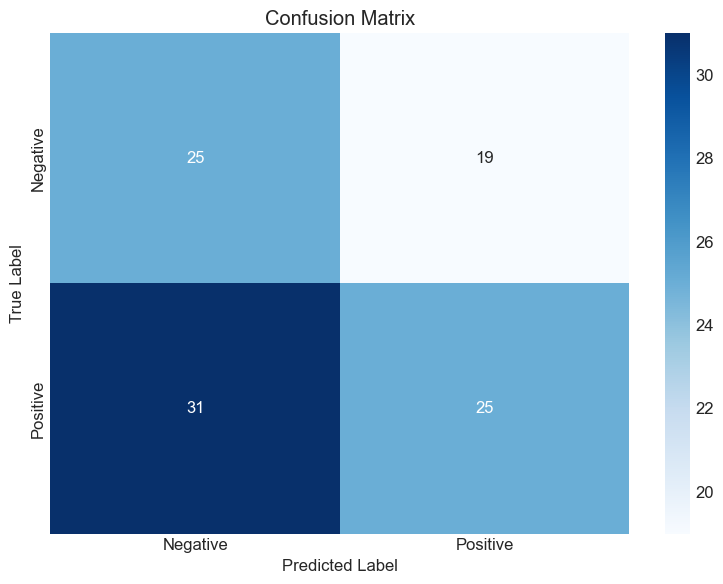

In [11]:
cm = plot_confusion_matrix(y_true, y_pred)

### Precision (Positive Predictive Value):
Out of all the instances the model *predicted* as positive, how many were actually positive?

$$Precision = \frac{True Positives}{Total Predicted Positives}$$

Using the confusion matrix:
$$Precision = \frac{TP}{TP + FP}$$

* **Focus:** Minimizing False Positives. High precision is important when the cost of a False Positive is high (e.g., classifying a non-spam email as spam, blocking a legitimate transaction).
* **Practical Example:** **Spam Filters.** You want to be very sure that an email is spam before moving it to the junk folder. You cannot afford to lose an important work email (False Positive).

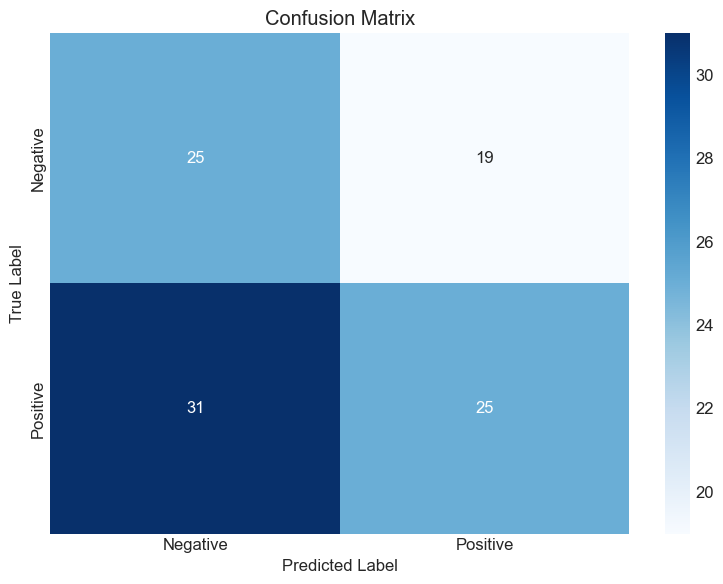

In [12]:
cm = plot_confusion_matrix(y_true, y_pred)

### Recall (Sensitivity, True Positive Rate):
Out of all the *actual* positive instances, how many did the model manage to find?

$$Recall = \frac{True Positives}{Total Actual Positives}$$

Using the confusion matrix:
$$Recall = \frac{TP}{TP + FN}$$
* **Focus:** Minimizing False Negatives. High recall is important when the cost of a False Negative is high
* **Practical Example:** **Cancer Diagnosis.** You want to find *every* patient who has cancer. It is acceptable to flag a healthy person for further testing (False Positive), but it is disastrous to tell a sick person they are healthy (False Negative).

### F1-Score:
The harmonic mean of Precision and Recall. It provides a single metric that balances the trade-off between the two. It's high only when both Precision and Recall are high.

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

Using the confusion matrix:
$$F1 = 2 \times \frac{TP}{2TP + FP + FN}$$
* **When to use:** Useful when you need a balance between minimizing `FPs` and `FNs`., and especially when there is an uneven class distribution (imbalanced data).

## Threshold-Independent Metrics
Classification models usually output a *probability* (e.g., 0.85 chance of rain), not a hard label. We choose a threshold (usually 0.5) to convert that probability into a class. Changing the threshold changes your Precision and Recall.

## 4.1.3 ROC Curves & AUC

### ROC Curve (Receiver Operating Characteristic Curve):
A plot of the **True Positive Rate (Recall)** against the **False Positive Rate**.

- **Axes:**
  - Y-axis: True Positive Rate (Recall) = $\frac{TP}{TP + FN}$
  - X-axis: False Positive Rate = $\frac{FP}{FP + TN}$
- **Interpretation:**
  - A diagonal line (TPR = FPR) represents a random classifier (no skill).
  - A curve that bows towards the top-left corner indicates better performance. The closer the curve is to the top-left, the better the model distinguishes between classes across all thresholds.

### AUC (Area Under the ROC Curve):
A single number summarizing the ROC curve.
- **Interpretation:**
  - AUC = 1.0: Perfect classifier.
  - AUC = 0.5: Random classifier (no discriminative ability).
  - AUC < 0.5: Worse than random (likely means labels are flipped or model is fundamentally flawed).
  - Generally, AUC > 0.7 is considered acceptable, > 0.8 good, > 0.9 excellent.
- **Benefit:** AUC is threshold-independent and useful for comparing different models, especially on balanced or mildly imbalanced datasets. *(Note: For highly imbalanced data, the Precision-Recall curve and its AUC might be more informative).*

Let's generate a ROC curve using sklearn:

In [19]:
# We need probability predictions for ROC curve, so let's create a simple logistic regression
# First, let's create some synthetic data with a clearer signal
from sklearn.datasets import make_classification

# Generate a synthetic binary classification dataset
X, y = make_classification(
    n_samples=1000, 
    n_classes=2, 
    n_features=20, 
    n_informative=10, 
    random_state=42
)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a logistic regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

# Get probability predictions
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]  # Probability of positive class (1)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_pred_proba)

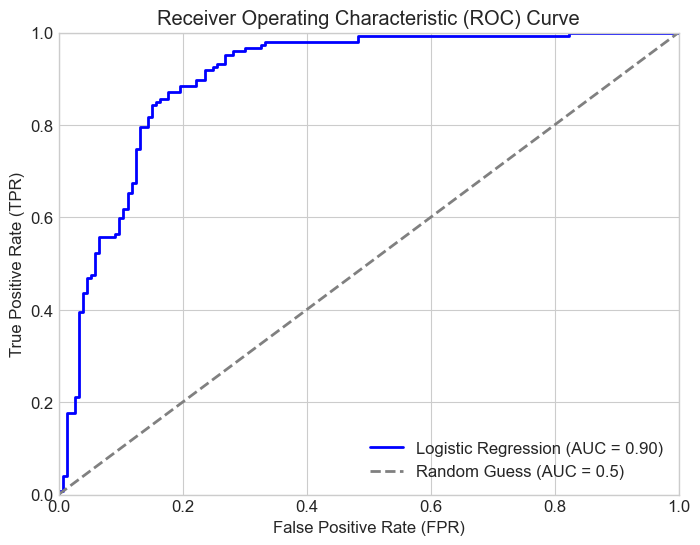

In [20]:
# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

In [21]:
# Print AUC score
print(f"AUC Score: {auc_score:.4f}")

AUC Score: 0.9032


In [22]:
# Let's also show how different thresholds affect the classification
thresholds_to_show = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
results = []

for threshold in thresholds_to_show:
    # Convert probabilities to class labels using the threshold
    y_pred_class = (y_pred_proba >= threshold).astype(int)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred_class)
    precision = precision_score(y_test, y_pred_class)
    recall = recall_score(y_test, y_pred_class)
    f1 = f1_score(y_test, y_pred_class)
    
    # Store results
    results.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

In [23]:
# Convert to DataFrame for easier display
results_df = pd.DataFrame(results)
print("\nEffect of different thresholds on metrics:")
print(results_df.round(4))


Effect of different thresholds on metrics:
   threshold  accuracy  precision  recall      f1
0        0.2    0.7867     0.7024  0.9796  0.8182
1        0.3    0.8267     0.7513  0.9660  0.8452
2        0.4    0.8300     0.7697  0.9320  0.8431
3        0.5    0.8333     0.7975  0.8844  0.8387
4        0.6    0.8333     0.8392  0.8163  0.8276
5        0.7    0.8100     0.8462  0.7483  0.7942
6        0.8    0.7667     0.8468  0.6395  0.7287


### Precision-Recall (PR) Curve
A plot of Precision vs. Recall for different thresholds.
* **Practical Note:** If your dataset is **heavily imbalanced** (e.g., Fraud Detection where only 0.1% of transactions are fraud), the ROC curve can be misleadingly optimistic. Always use the PR Curve for imbalanced datasets.

## Practical Scenarios: Which Metric to Choose?

As an engineer, your choice of metric depends on the **business problem** and the **cost of errors**.

| Scenario | Business Goal | Metric to Optimize |
| :--- | :--- | :--- |
| **Stock Market Prediction** | You want to buy only when you are absolutely sure the price will go up. | **Precision** (Avoid bad buys) |
| **COVID-19 Screening** | You must catch every infected person to stop the spread. | **Recall** (Don't miss cases) |
| **Fraud Detection** | Fraud is rare (imbalanced). You want to catch fraud without blocking too many legit cards. | **F1-Score** or **PR-AUC** |
| **YouTube Recommendations** | You want users to generally like what they see. | **Accuracy** or **ROC-AUC** |

## 5. Advanced: Log Loss (Cross-Entropy Loss)
While Accuracy looks at "Right vs. Wrong," **Log Loss** looks at **confidence**.
* If the model predicts a generic email is Spam with 51% confidence, and it is wrong, the penalty is small.
* If the model predicts it is Spam with 99% confidence, and it is wrong, the penalty is massive.
* **Use this when:** The *probability* estimate itself matters (e.g., predicting the probability of a click for ad pricing).


## 6. Multi-Class Evaluation
When you have more than two classes (e.g., classifying images of Cats, Dogs, and Birds), you average the metrics:

* **Macro Average:** Calculate the metric for each class (Cat, Dog, Bird) and take the average. *Treats all classes equally, even if one is rare.*
* **Micro Average:** Aggregate all TP, FP, and FN across all classes and calculate the metric. *Heavily influenced by the majority class.*

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, 
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    average_precision_score, 
    log_loss, 
    classification_report, 
    roc_curve, 
    precision_recall_curve
)

In [26]:

# 1. Generate a synthetic dataset (slightly imbalanced to make it realistic)
# Weights=[0.7, 0.3] means 70% of data is Class 0, 30% is Class 1
X, y = make_classification(
    n_samples=1000, 
    n_features=20, 
    n_classes=2, 
    weights=[0.7, 0.3], 
    random_state=42
)

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [27]:

# 3. Train Model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 4. Predictions
# Hard classes (0 or 1) for Accuracy/Precision/Recall/F1
y_pred = model.predict(X_test)                 
# Probabilities (0.0 to 1.0) for ROC-AUC/LogLoss
y_proba = model.predict_proba(X_test)[:, 1]    


In [34]:

# 5. Calculate Metrics
conf_matrix = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
ll = log_loss(y_test, y_proba)

# Print Text Metrics
print("=== Classification Metrics Report ===")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc_auc:.4f}")
print(f"PR AUC:    {pr_auc:.4f}")
print(f"Log Loss:  {ll:.4f}")

=== Classification Metrics Report ===
Accuracy:  0.8800
Precision: 0.8250
Recall:    0.7500
F1 Score:  0.7857
ROC AUC:   0.9042
PR AUC:    0.8762
Log Loss:  0.3182


In [30]:

print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred))


=== Detailed Classification Report ===
              precision    recall  f1-score   support

           0       0.90      0.93      0.92       212
           1       0.82      0.75      0.79        88

    accuracy                           0.88       300
   macro avg       0.86      0.84      0.85       300
weighted avg       0.88      0.88      0.88       300



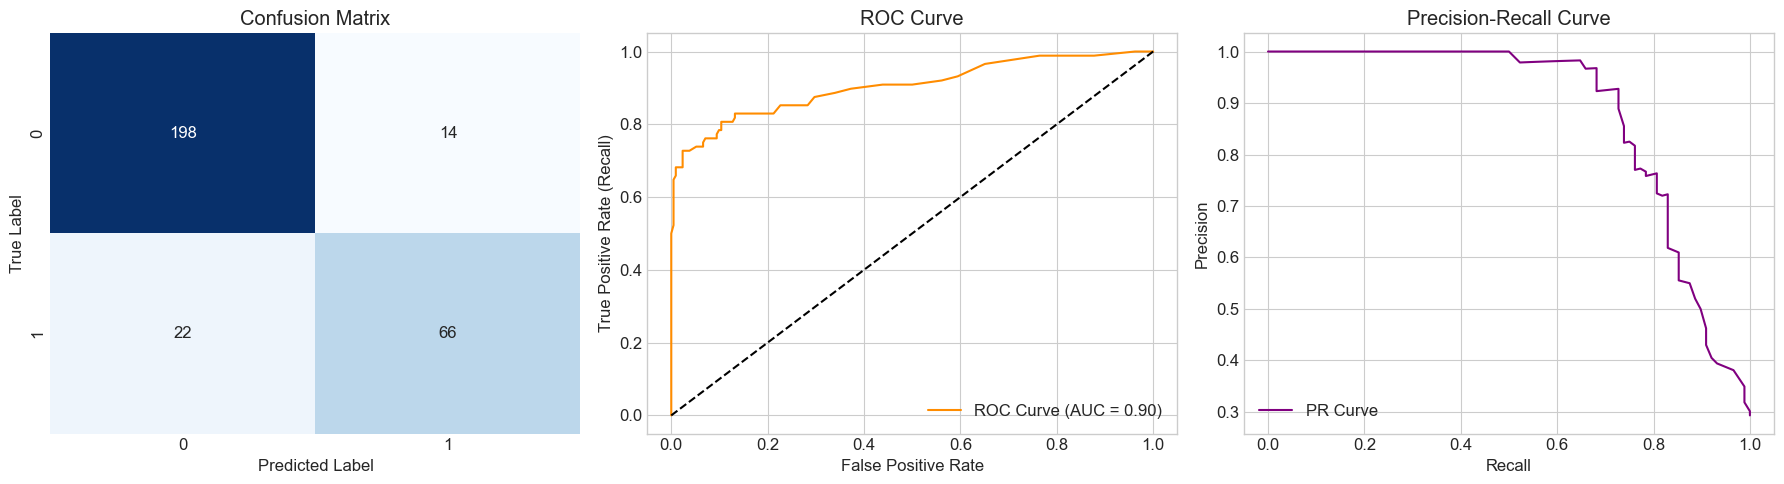

In [31]:

# 6. Visualization
plt.figure(figsize=(18, 5))

# Plot 1: Confusion Matrix
plt.subplot(1, 3, 1)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Plot 2: ROC Curve
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--') # Diagonal random guess line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')

# Plot 3: Precision-Recall Curve
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)
plt.subplot(1, 3, 3)
plt.plot(recall, precision, label='PR Curve', color='purple')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')

plt.tight_layout()
plt.show()

### The Output Interpretation

**From the text report:**

  * **Accuracy (0.88):** 88% of predictions were correct.
  * **Precision (0.825):** When the model claimed a sample was Positive (Class 1), it was correct 82.5% of the time.
  * **Recall (0.75):** The model successfully found 75% of the actual Positive cases.
  * **F1 Score (0.786):** The balance between Precision and Recall.
  * **ROC AUC (0.904):** A score of 0.9 is generally considered excellent discrimination.


  * **PR AUC (0.8762):** This number summarizes the quality of the Precision-Recall curve.
  * **Why it matters:** In this dataset (30% positive), the **ROC AUC is 0.90**, which looks "perfect." However, the **PR AUC is 0.87**.
  * If the data were even more imbalanced (e.g., 5% positive), you would often see ROC AUC stay high (e.g., 0.95) while PR AUC drops significantly (e.g., 0.60), revealing that the model isn't actually good at finding the rare class without generating many false alarms. **Always trust PR AUC over ROC AUC for imbalanced data.**


**From the Visualizations:**

1.  **Confusion Matrix:** Look at the off-diagonal numbers.
      * **Upper Right (14):** False Positives. These are the "False Alarms."
      * **Lower Left (22):** False Negatives. These are the "Missed Opportunities."
2.  **ROC Curve:** The curve bows nicely toward the top-left corner, confirming the high AUC score (0.90). This indicates the model separates the two classes well.
3.  **PR Curve:** Since our data is imbalanced (30% positives), this curve is crucial. It shows that as we try to increase Recall (moving right), our Precision stays relatively high until about 0.8 recall, after which it drops sharply. This helps you pick a threshold: do you want 0.9 Recall with only 0.6 Precision? Or 0.7 Recall with 0.9 Precision?

## Knowledge Check

1. What is the key difference between accuracy and precision as evaluation metrics?
2. In a confusion matrix, which cell represents false positives?
3. If a model has high recall but low precision, what does that tell you about its predictions?
4. Why is AUC a useful metric for comparing different classification models?
5. In which situation would accuracy be a misleading metric for model performance?

## Mini-Challenges

### Challenge 1: Interpreting a Confusion Matrix
Given the following confusion matrix for a model predicting whether emails are spam (1) or not spam (0):

In [29]:
[TN=850, FP=50]
[FN=30, TP=70]

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (1428874480.py, line 1)

Calculate:
1. Accuracy
2. Precision for spam detection
3. Recall for spam detection
4. F1-score

### Challenge 2: Threshold Adjustment
Using the Breast Cancer model we trained:
1. Experiment with different classification thresholds (0.3, 0.5, 0.7)
2. Observe how precision and recall change
3. Find a threshold that maximizes F1-score

In [ ]:
# Starter code
thresholds_to_try = [0.3, 0.5, 0.7]
for threshold in thresholds_to_try:
    # Convert probabilities to predictions using the threshold
    y_pred_at_threshold = (y_pred_proba >= threshold).astype(int)
    
    # Calculate metrics
    # Your code here
    
    # Print results
    print(f"Threshold: {threshold}")
    print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

### Challenge 3: Comparing Models
Train a different classifier (e.g., Random Forest or SVM) on the same data and compare the evaluation metrics with the Logistic Regression model.

## Practical Connections

- **Medical Diagnostics**: When developing models for cancer detection, false negatives (missing a cancer diagnosis) are usually much more costly than false positives, making recall more important than precision.

- **Spam Filtering**: For email spam detection, a balance is needed - too many false positives (legitimate emails marked as spam) creates user frustration, while false negatives (spam in your inbox) reduces the filter's usefulness.

- **Fraud Detection**: Credit card fraud detection models often deal with highly imbalanced data (most transactions are legitimate) where both precision and recall are important - you want to catch fraud without inconveniencing customers with false alarms.

- **Content Moderation**: Social media platforms use classification models to flag inappropriate content, where the cost of false negatives (allowing harmful content) must be balanced against false positives (incorrectly removing legitimate content).

- **Quality Control**: In manufacturing, models that detect defective products need high recall to ensure product quality, but also reasonable precision to avoid unnecessary waste.